In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/retail_clean.parquet")
df.shape

(779425, 13)

Chart 1: Daily revenue trend

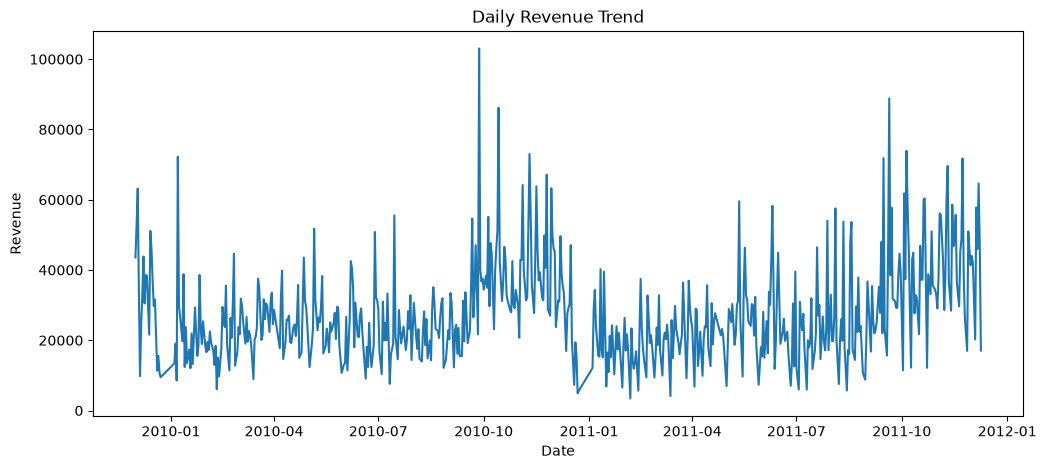

In [2]:
daily = df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
daily.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.savefig("../reports/figures/daily_revenue_trend.png")
plt.show()

Chart 2: Top 10 products by revenue

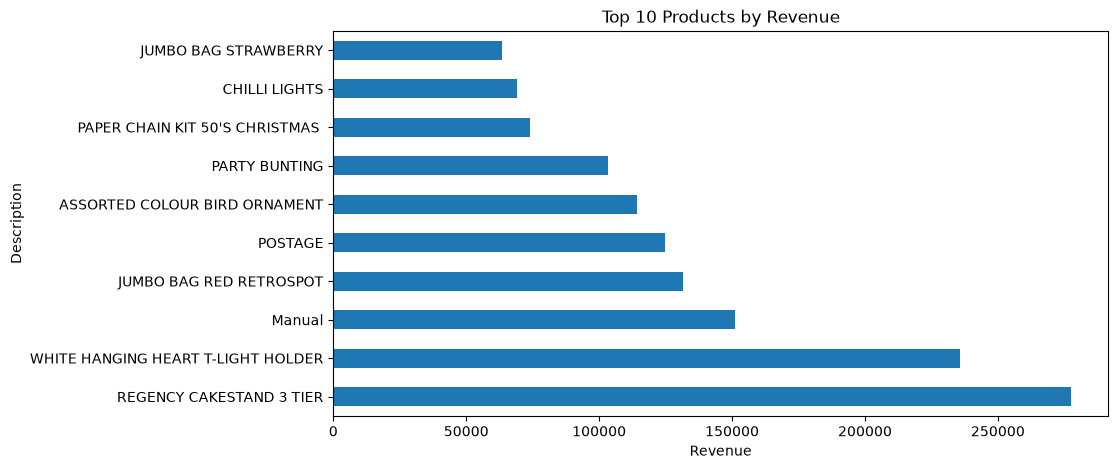

In [3]:
top_products = df.groupby("Description")["TotalPrice"].sum().nlargest(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.savefig("../reports/figures/top_products.png")
plt.show()

Chart 3: Revenue by weekday

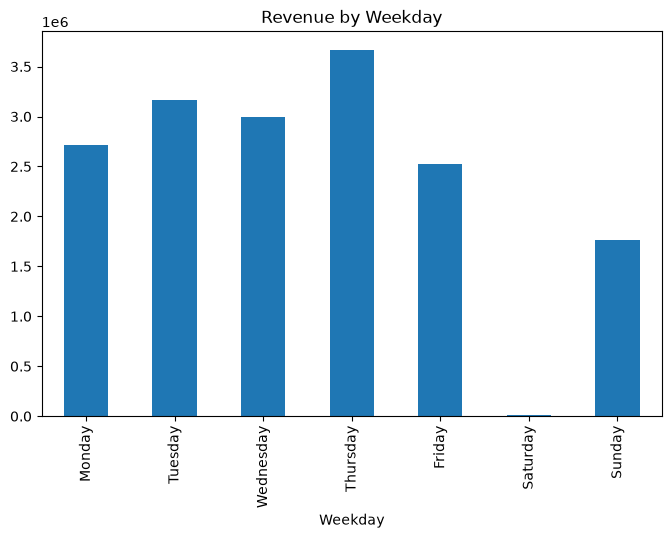

In [4]:
weekday_revenue = df.groupby("Weekday")["TotalPrice"].sum()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_revenue = weekday_revenue.reindex(order)

plt.figure(figsize=(8, 5))
weekday_revenue.plot(kind="bar")
plt.title("Revenue by Weekday")
plt.savefig("../reports/figures/revenue_by_weekday.png")
plt.show()

Chart 4: Top 10 countries (excluding UK)

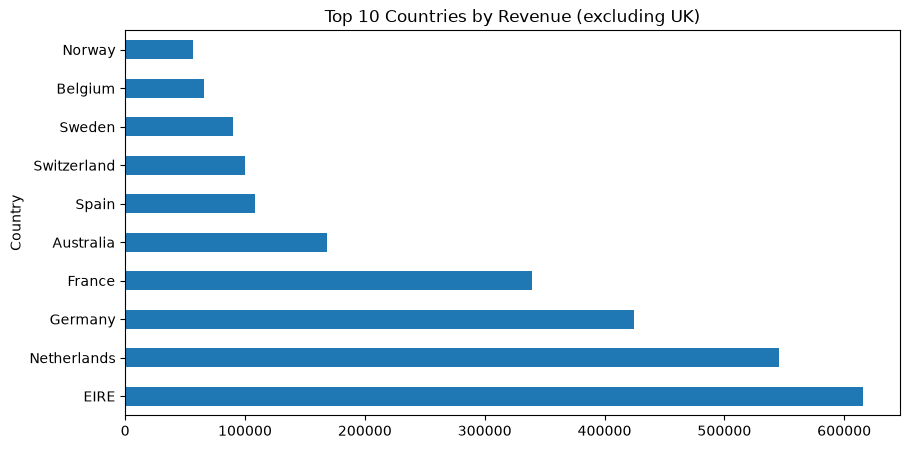

In [5]:
country_revenue = df[df["Country"] != "United Kingdom"].groupby("Country")["TotalPrice"].sum().nlargest(10)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind="barh")
plt.title("Top 10 Countries by Revenue (excluding UK)")
plt.savefig("../reports/figures/top_countries.png")
plt.show()